In [1]:
#========================================================================
# Name: coarse_grain_regrid_csapr.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
# Date Created: 02/04/2025
#
# Utility: Coarse-grains and regrids CSAPR reflectivity, rain rate,
# and rain water content to match WRF resolution (3-km currently).
# Regridding isn't necessary statistically, but is useful because the
# GOES data is coarse-grained and regridded to the WRF grid already.
#========================================================================

In [2]:
#===============================
# Imports
#===============================
# Always load these
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import datetime
import os
import sys
import matplotlib as mpl
import time

# Specific to this script
from pytz import utc
import dask
from dask.distributed import wait
from distributed import Client, LocalCluster
import logging
from scipy import ndimage
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator

# Home-made functions
#from functions import find_nearest


#import cartopy.crs as ccrs
#import cartopy.feature as cfeature
#from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#import cartopy.io.img_tiles as cimgt
#import shapely.geometry as sgeom
#import matplotlib.patheffects as path_effects
#from matplotlib.collections import PatchCollection
#from matplotlib.patches import Rectangle, Patch
#from matplotlib.lines import Line2D
#import matplotlib.colors as colors
#import matplotlib.gridspec as gridspec


import warnings
warnings.filterwarnings("ignore")

In [3]:
def create_semi_symmetric_array(size):
    """
    Make a semi-symmetric array around 0 increment by 1

    If the size is even, the array starts from -(size // 2) + 1 and goes up to start + size - 1 
    (e.g., for size = 10, the array would be [-4, -3, -2, -1, 0, 1, 2, 3, 4, 5]). 
    If the size is odd, the array starts from -(size // 2) and goes up to start + size - 1 
    (e.g., for size = 9, the array would be [-4, -3, -2, -1, 0, 1, 2, 3, 4]).

    Args:
        size: int
            Size of the array.

    Returns:
        np.array
    """
    if size % 2 == 0:
        start = -(size // 2) + 1
    else:
        start = -(size // 2)
    array = np.arange(start, start + size)
    return array

In [12]:
def regrid_csapr(config):
#def regrid_csapr(in_path=None,out_path=None,iparallel=False,out_basename=None):
    """
    Driver to coarsen CSPAR 3D data.
    Potential variables include reflectivity, rain rate, and rain water content

    Args:
        config: dictionary
            Dictionary containing config parameters.

    Returns:
        None.
    """
    
    in_path = config['in_path']
    out_path = config['out_path']
    iparallel = config['iparallel']
    #out_basename = config['out_basename']
    start_id = config['start_id']
    end_id = config['end_id']

    if iparallel:
        logger = logging.getLogger(__name__)
        logger.info('Coarse-graining & regridding CSAPR reflectivity')
    elif not iparallel:
        print('Coarse-graining & regridding CSAPR reflectivity')
        
    
    #in_dir = config['rawdata_path']
    #in_basename = config['rawdatabasename']
    #out_dir = config["clouddata_path"]
    #out_basename = config['databasename']
    #run_parallel = config['run_parallel']
    #start_basetime = config["start_basetime"]
    #end_basetime = config["end_basetime"]
    #time_format = config["time_format"]

    #os.makedirs(out_dir, exist_ok=True)

    #########################################################################################
    # Identify files to process
    #infiles_info = subset_files_timerange(
    #    in_dir,
    #    in_basename,
    #    start_basetime,
    #    end_basetime,
    #    time_format=time_format,
    #)
    # Get file list
    #in_files = infiles_info[0]
    #nfiles = len(in_files)
    #logger.info(f"Total number of files to process: {nfiles}")
    
    in_files = sorted(glob.glob(in_path+'*.nc'))[start_id:end_id]
    num_in_files = len(in_files)

    if iparallel:
        logger.info('Total number of files to process',num_in_files)
    elif not iparallel:
        print('# of files to process:',num_in_files)

    results = []
    for ifile in in_files:
        # Parallel
        if iparallel:
            #result = dask.delayed(regrid_file)(ifile, in_basename, out_dir, out_basename, config)
            result = dask.delayed(regrid_file)(ifile, config, iparallel)
            results.append(result)
        # Serial
        elif not iparallel:
            result = regrid_file(ifile, config, iparallel)
        else:
            sys.exit('Valid parallelization flag not provided')

    if iparallel:
        # Trigger dask computation
        final_result = dask.compute(*results)
        wait(final_result)

    if iparallel:
        logger.info('Done coarse-graining and regridding reflectivity files')
    elif not iparallel:
        print('Done coarse-graining and regridding reflectivity files')
        
    return

In [13]:
def regrid_file(in_filename, config, iparallel=False):
    """
    Regrid a file containing reflectivity, rain rate, and rain water content data.

    Args:
        in_filename: string
            Input file name.
        iparallel: Bool
            Boolean for whether or not running parallel.
            Default is False.
        config: dictionary
            Dictionary containing config parameters.
    
    Returns:
        out_filename: string
            Output file name.
    """
    if iparallel:
        logger = logging.getLogger(__name__)

    time_dimname = config.get('time_dimname', 'time')
    lon_varname = config.get('lon_varname', 'lon')
    lat_varname = config.get('lat_varname', 'lat')
    x_varname = config.get('x_varname', 'x')
    y_varname = config.get('y_varname', 'y')
    z_varname = config.get('z_varname', 'z')
    x_dimname = config.get('x_dimname', 'x')
    y_dimname = config.get('y_dimname', 'y')
    z_dimname = config.get('z_dimname', 'z')
    in_basename = config.get('in_basename')
    out_basename = in_basename
    out_endname = config.get('out_endname')
    in_path = config.get('in_path')
    out_path = config.get('out_path')

    
    dx = config['dx']
    dy = config['dy']
    regrid_ratio = config.get('regrid_ratio')
    num_vars2regrid = config.get('num_vars2regrid')

    num_vars2regrid = config.get('num_vars2regrid')
    vars2regrid_names = config.get('vars2regrid_names')
    vars_reflectivity_bool = config.get('vars_reflectivity_bool')
    
    non_ref_vars = {}
    for ii in range(num_vars2regrid):
        if vars_reflectivity_bool[ii]:
            reflectivity_varname = config['vars2regrid_names'][ii]
        else:
            non_ref_vars[config['vars2regrid_names'][ii]] = None
    non_ref_vars_keys = list(non_ref_vars.keys())
    num_non_ref_vars = len(non_ref_vars_keys)
    
    # Read input data
    ds = xr.open_dataset(in_filename)
    in_time = ds[time_dimname]
    radar_lon_attrs = ds['origin_longitude'].attrs
    radar_lat_attrs = ds['origin_latitude'].attrs
    radar_alt = ds['alt']
    REFL = ds[reflectivity_varname].squeeze()
    ncp = ds['normalized_coherent_power'].squeeze()
    # REFL_MAX = ds['REFL_MAX'].squeeze()
    longitude = ds[lon_varname]
    latitude = ds[lat_varname]
    for ii in range(num_non_ref_vars):
        non_ref_vars[non_ref_vars_keys[ii]] = ds[non_ref_vars_keys[ii]].squeeze()

    # Make a kernel for weights
    start_idx = int((regrid_ratio-1) / 2)
    kernel = np.zeros((regrid_ratio+1,regrid_ratio+1), dtype=int)
    kernel[1:regrid_ratio, 1:regrid_ratio] = 1

    # Make a 3D kernel
    kernel3d = kernel[None,:,:]
    # Call convlution function
    REFL_conv = convolve_reflectivity(REFL.data, kernel3d)
    ncp_conv = convolve_var(ncp.data, kernel3d)
    vars_conv = {}
    for ii in range(num_non_ref_vars):
        vars_conv[non_ref_vars_keys[ii]] = convolve_var(non_ref_vars[non_ref_vars_keys[ii]].data,kernel3d)

    # Subsample every X grid points
    REFL_reg = REFL_conv[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
    ncp_reg = ncp_conv[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
    longitude_reg = longitude.data[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
    latitude_reg = latitude.data[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
    non_ref_vars_reg = {}
    for ii in range(num_non_ref_vars):
        non_ref_vars_reg[non_ref_vars_keys[ii]] = vars_conv[non_ref_vars_keys[ii]][:,start_idx::regrid_ratio,start_idx::regrid_ratio]
        
    
    # Grab a WRF file to get lon/lat grid
    wrf_path = config.get('wrf_path')
    wrf_files = sorted(glob.glob(wrf_path+'*.nc'))
    wrf_file = wrf_files[0]
    
    ds_wrf = xr.open_dataset(wrf_file)
    wrf_lon = ds_wrf['XLONG'].values
    wrf_lat = ds_wrf['XLAT'].values
    ds_wrf.close()
    
    longitude_reg_2d = longitude_reg[0,:,:]
    latitude_reg_2d = latitude_reg[0,:,:]
    
    REFL_reg_interp = interpolate_3d_to_new_grid(REFL_reg,latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)
    ncp_reg_interp = interpolate_3d_to_new_grid(ncp_reg,latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)
    non_ref_vars_reg_interp = {}
    for ii in range(num_non_ref_vars):
        non_ref_vars_reg_interp[non_ref_vars_keys[ii]] =  interpolate_3d_to_new_grid(non_ref_vars_reg[non_ref_vars_keys[ii]],latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)

    longitude_reg_interp = wrf_lon
    latitude_reg_interp = wrf_lat
    
    
    # Make output filename
    in_filename = in_filename.split('/')[-1]
    nleadingchar = len(f'{in_basename}')
    fname = os.path.basename(in_filename)
    ftimestr = fname[nleadingchar:].split('_')[0]
    out_filename = f'{out_path}{out_basename}{ftimestr}{out_endname}'
    dx = config.get('dx')
    dy = config.get('dy')
    
    # Make output coordinate
    nz, ny, nx = REFL_reg_interp.shape
    xcoord = create_semi_symmetric_array(nx) * dx
    ycoord = create_semi_symmetric_array(ny) * dy
    xcoord_attrs = ds[x_varname].attrs
    ycoord_attrs = ds[y_varname].attrs
    # Get radar lat/lon from the regridded lat/lon
    xid0 = np.nanargmin(np.absolute(xcoord - 0))
    yid0 = np.nanargmin(np.absolute(ycoord - 0))
    radar_lon = longitude_reg_interp[yid0, xid0]
    radar_lat = latitude_reg_interp[yid0, xid0]
    # Expand dimension if needed
    if np.isscalar(radar_lon): radar_lon = np.expand_dims(radar_lon, axis=0)
    if np.isscalar(radar_lat): radar_lat = np.expand_dims(radar_lat, axis=0)
    
    
    longitude_reg_interp_out = np.tile(longitude_reg_interp, (ds['z'].size,1,1))
    latitude_reg_interp_out = np.tile(latitude_reg_interp, (ds['z'].size,1,1))
    
    # Define output variablesf
    var_dict = {
        lon_varname: ([z_dimname, y_dimname, x_dimname], longitude_reg_interp_out, longitude.attrs),
        lat_varname: ([z_dimname, y_dimname, x_dimname], latitude_reg_interp_out, latitude.attrs),
        reflectivity_varname: ([time_dimname, z_dimname, y_dimname, x_dimname], np.expand_dims(REFL_reg_interp, axis=0), REFL.attrs),
        'normalized_coherent_power': ([time_dimname, z_dimname, y_dimname, x_dimname], np.expand_dims(ncp_reg_interp, axis=0), ncp.attrs),
        non_ref_vars_keys[0]: ([time_dimname, z_dimname, y_dimname, x_dimname], np.expand_dims(non_ref_vars_reg_interp[non_ref_vars_keys[0]], axis=0), ds[non_ref_vars_keys[0]].attrs),
        non_ref_vars_keys[1]: ([time_dimname, z_dimname, y_dimname, x_dimname], np.expand_dims(non_ref_vars_reg_interp[non_ref_vars_keys[1]], axis=0), ds[non_ref_vars_keys[1]].attrs),
        'origin_longitude': ([time_dimname], radar_lon, radar_lon_attrs),
        'origin_latitude': ([time_dimname], radar_lat, radar_lat_attrs),
        'alt': ([time_dimname], np.expand_dims(radar_alt.data, axis=0), radar_alt.attrs),
    }
    
    # Output coordinates
    coord_dict = {
        time_dimname: ([time_dimname], in_time.data),
        z_varname: ([z_dimname], ds[z_varname].data, ds[z_varname].attrs),
        y_dimname: ([y_dimname], ycoord, ycoord_attrs),
        x_dimname: ([x_dimname], xcoord, xcoord_attrs),
    }
    
    
    # Output global attributes
    gattr_dict = {
        'Title': 'Coarse-grained and regridded CSAPR reflectivity.',
        'Description_1':'Coarse-grained from native 500-m resolution to 3-km resolutions',
        'Description_2':'Re-gridded to match WRF 3-km CACTI simulation grid spacing.',
        'DX': dx,
        'DY': dy,
        'Contact': 'McKenna Stanford, mckenna.stanford@pnnl.gov',
        'Institution': 'Pacific Northwest National Laboratory',
        'Created_on': time.ctime(time.time()),
    }
    
    # Define xarray dataset
    ds_out = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)
    
    
    # Set encoding/compression for all variables
    comp = dict(zlib=True)
    encoding = {var: comp for var in ds_out.data_vars}
    
    # Write to netcdf file
    ds_out.to_netcdf(
        path=out_filename+'.nc', mode='w', format='NETCDF4', unlimited_dims=time_dimname, encoding=encoding,
    )
    
    if iparallel:
        logger.info(f'{out_filename}')
    elif not iparallel:
        print(out_filename)
        
    return out_filename 

In [6]:
def convolve_reflectivity(in_reflectivity, kernel):
    """
    Apply convolution to reflectivity within a moving kernel.
    This is equivalent to averaging reflectivity within a moving window.

    Args:
        in_reflectivity: np.array
            Input reflectivity array, can be either 2D or 3D.
        kernel: np.array
            Kernel for weights.
    
    Returns:
        out_reflectivity: np.array
            Output reflectivity array.
    """
    # Convert reflectivity to linear unit
    linrefl = 10. ** (in_reflectivity / 10.)
    # Make an array for counting number of grids for convolution
    mask_goodvalues = (~np.isnan(in_reflectivity)).astype(float)

    # Apply convolution filter
    bkg_linrefl = ndimage.convolve(linrefl, kernel, mode='constant', cval=0.0)
    numPixs = ndimage.convolve(mask_goodvalues, kernel, mode='constant', cval=0.0)
    # Mask missing data area
    bkg_linrefl[mask_goodvalues==0] = 0
    numPixs[mask_goodvalues==0] = 0

    # Calculate average linear reflectivity and convert to log values
    out_reflectivity = np.full(in_reflectivity.shape, np.NaN, dtype=np.float32)
    out_reflectivity[numPixs>0] = 10.0 * np.log10(bkg_linrefl[numPixs>0] / numPixs[numPixs>0])

    # Remove pixels with 0 number of pixels
    out_reflectivity[mask_goodvalues==0] = np.NaN
    
    return out_reflectivity

In [7]:
def convolve_var(in_var, kernel):
    """
    Apply convolution to a variable within a moving kernel.

    Args:
        in_var: np.array
            Input variable array, can be either 2D or 3D.
        kernel: np.array
            Kernel for weights.
    
    Returns:
        out_var: np.array
            Output variable array.
    """
    # Make an array for counting number of grids for convolution
    mask_goodvalues = (~np.isnan(in_var)).astype(float)

    # Apply convolution filter
    bkg_var = ndimage.convolve(in_var, kernel, mode='constant', cval=0.0)
    numPixs = ndimage.convolve(mask_goodvalues, kernel, mode='constant', cval=0.0)
    # Mask missing data area
    bkg_var[mask_goodvalues==0] = 0
    numPixs[mask_goodvalues==0] = 0

    # Calculate average linear reflectivity and convert to log values
    out_var = np.full(in_var.shape, np.NaN, dtype=np.float32)
    out_var[numPixs>0] = bkg_var[numPixs>0] / numPixs[numPixs>0]

    # Remove pixels with 0 number of pixels
    out_var[mask_goodvalues==0] = np.NaN

    return out_var

In [8]:
def interpolate_3d_to_new_grid(in_var, in_lat, in_lon, out_lat, out_lon):
    """
    Perform bilinear interpolation on a 3D array with NaN retention using RegularGridInterpolator.
    Uses nearest-neighbor approach because linear interpolation created many issues with interpolating over NaNs.
    The nearest-neightbor approach looks very similar to the native grid, which is what we wanted because 
        the new grid is not much different from the original grid.
    
    Parameters:
    in_var (numpy.ndarray): 3D array of shape (alt, y_points, x_points) containing input data.
    in_lat (numpy.ndarray): 2D array of latitudes corresponding to in_var, shape (y_points, x_points).
    in_lon (numpy.ndarray): 2D array of longitudes corresponding to in_var, shape (y_points, x_points).
    out_lat (numpy.ndarray): 2D array of latitudes for interpolation, shape (new_y_points, new_x_points).
    out_lon (numpy.ndarray): 2D array of longitudes for interpolation, shape (new_y_points, new_x_points).
    
    Returns:
    numpy.ndarray: Interpolated 3D array with shape (alt, new_y_points, new_x_points).
    """

    # -------------------------
    # Specific to LASSO
    #out_lon = out_lon[0,:,:]
    #ut_lat = out_lat[0,:,:]
    # -------------------------
    alt_levels = in_var.shape[0]
    output_shape = (alt_levels, out_lat.shape[0], out_lon.shape[1])
    out_var = np.full(output_shape, np.nan)  # Initialize with NaNs

    # Create a RegularGridInterpolator for each altitude level
    for i in range(alt_levels):
        #print(i)
        # Mask the NaNs in in_var at the current altitude level
        valid_mask = ~np.isnan(in_var[i])
        
        if np.any(valid_mask):  # Only interpolate if there are valid data points
            # Use the valid mask to extract non-NaN lat/lon and values
            valid_lat = in_lat[valid_mask]
            valid_lon = in_lon[valid_mask]
            valid_values = in_var[i][valid_mask]

            # Create a RegularGridInterpolator for this altitude level
            interpolator = RegularGridInterpolator(
                (in_lat[:, 0], in_lon[0, :]),  # Specify the input grid
                in_var[i],  # Data values for interpolation
                bounds_error=False,  # Allow extrapolation beyond the grid
                method='nearest',
                fill_value=np.nan  # Use NaN where no valid data exists
            )


            if True:
                points_to_interpolate = np.array([out_lat.ravel(), out_lon.ravel()]).T  # Shape (new_y_points * new_x_points, 2)
                interpolated_values = interpolator(points_to_interpolate)
                # Reshape to desired output grid
                out_var[i, :, :] = interpolated_values.reshape(out_lat.shape)
            
            if False:
                # Perform interpolation on the new lat/lon grid
                for y_idx in range(out_lat.shape[0]):
                    for x_idx in range(out_lon.shape[1]):
                        # For each (out_lat, out_lon) coordinate, interpolate the value
                        lat_val = out_lat[y_idx, x_idx]
                        lon_val = out_lon[y_idx, x_idx]
                        # Get interpolated value, which will return NaN if out-of-bounds
                        #print(i)
                        #print(y_idx)
                        #print(x_idx)
                        #print(lat_val)
                        #print(lon_val)
                        out_var[i, y_idx, x_idx] = interpolator((lat_val, lon_val))

    return out_var


# Start dask client

In [9]:
dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

In [10]:
#cluster = LocalCluster(n_workers=64,threads_per_worker=1)
cluster = LocalCluster(n_workers=100,threads_per_worker=1,memory_limit='4GB')#,dashboard_address=':8787')
client = Client(cluster)

In [11]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 100
Total threads: 100,Total memory: 372.53 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38057,Workers: 100
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 100
Started: Just now,Total memory: 372.53 GiB
Comm: tcp://127.0.0.1:34713,Total threads: 1
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:37029/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:36651,


# Get the scheduler information

# Configure the job

In [19]:
config = {
    'in_path':'/global/cfs/projectdirs/m1657/avarble/cacti/Taranis/taranis_corcsapr2cfrppiqcM1_gridded.c1/',
    'out_path':'/pscratch/sd/m/mckenna/cacti/csapr_coarse_grained_regridded/3km/',
    'iparallel':True,
    #'out_basename':'csapr_coarse_grain_regrid',
    'out_endname':'_coarse_grained_regridded',
    'in_basename':'taranis_corcsapr2cfrppiqcM1.c1.',
    'num_vars2regrid':3,
    'vars2regrid_names':['taranis_attenuation_corrected_reflectivity','taranis_rain_rate','lwc_combined'],
    'vars_reflectivity_bool':[True,False,False],
    'time_dimname':'time',
    'x_dimname':'x',
    'y_dimname':'y',
    'z_dimname':'z',
    'time_varname':'time',
    'x_varname':'x',
    'y_varname':'y',
    'z_varname':'z',
    'lon_varname':'point_longitude',
    'lat_varname':'point_latitude',
    'dx':3000,
    'dy':3000,
    'regrid_ratio':6,
    'wrf_path':'/global/homes/m/mckenna/cacti_data/3km/csapr/',
    #'wrf_path':'/pscratch/sd/m/mckenna/wrf_lasso/20181129/gefs03/cntl/',
    'start_id':0,
    'end_id':8027,
    #'end_id':3002,
}

# Run driver function

In [20]:
start_time = time.time()
regrid_csapr(config)
end_time = time.time()
elapsed_time = end_time - start_time
print('Total processing time:',elapsed_time/60.,'minutes')

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-pac

Total processing time: 7.191548152764638 minutes


In [36]:
# Get total number of files
num_files = len(glob.glob(config['in_path']+'*.nc'))
print(num_files)

8027


In [17]:
#client

In [51]:
def interpolate_3d_to_new_grid(in_var, in_lat, in_lon, out_lat, out_lon):
    """
    Perform bilinear interpolation on a 3D array with NaN retention using RegularGridInterpolator.
    Uses nearest-neighbor approach because linear interpolation created many issues with interpolating over NaNs.
    The nearest-neightbor approach looks very similar to the native grid, which is what we wanted because 
        the new grid is not much different from the original grid.
    
    Parameters:
    in_var (numpy.ndarray): 3D array of shape (alt, y_points, x_points) containing input data.
    in_lat (numpy.ndarray): 2D array of latitudes corresponding to in_var, shape (y_points, x_points).
    in_lon (numpy.ndarray): 2D array of longitudes corresponding to in_var, shape (y_points, x_points).
    out_lat (numpy.ndarray): 2D array of latitudes for interpolation, shape (new_y_points, new_x_points).
    out_lon (numpy.ndarray): 2D array of longitudes for interpolation, shape (new_y_points, new_x_points).
    
    Returns:
    numpy.ndarray: Interpolated 3D array with shape (alt, new_y_points, new_x_points).
    """

    # -------------------------
    # Specific to LASSO
    #out_lon = out_lon[0,:,:]
    #ut_lat = out_lat[0,:,:]
    # -------------------------
    alt_levels = in_var.shape[0]
    output_shape = (alt_levels, out_lat.shape[0], out_lon.shape[1])
    out_var = np.full(output_shape, np.nan)  # Initialize with NaNs

    # Create a RegularGridInterpolator for each altitude level
    for i in range(alt_levels):
        #print(i)
        # Mask the NaNs in in_var at the current altitude level
        valid_mask = ~np.isnan(in_var[i])
        
        if np.any(valid_mask):  # Only interpolate if there are valid data points
            # Use the valid mask to extract non-NaN lat/lon and values
            valid_lat = in_lat[valid_mask]
            valid_lon = in_lon[valid_mask]
            valid_values = in_var[i][valid_mask]

            # Create a RegularGridInterpolator for this altitude level
            interpolator = RegularGridInterpolator(
                (in_lat[:, 0], in_lon[0, :]),  # Specify the input grid
                in_var[i],  # Data values for interpolation
                bounds_error=False,  # Allow extrapolation beyond the grid
                method='nearest',
                fill_value=np.nan  # Use NaN where no valid data exists
            )


            if True:
                points_to_interpolate = np.array([out_lat.ravel(), out_lon.ravel()]).T  # Shape (new_y_points * new_x_points, 2)
                interpolated_values = interpolator(points_to_interpolate)
                # Reshape to desired output grid
                out_var[i, :, :] = interpolated_values.reshape(out_lat.shape)
            
            if False:
                # Perform interpolation on the new lat/lon grid
                for y_idx in range(out_lat.shape[0]):
                    for x_idx in range(out_lon.shape[1]):
                        # For each (out_lat, out_lon) coordinate, interpolate the value
                        lat_val = out_lat[y_idx, x_idx]
                        lon_val = out_lon[y_idx, x_idx]
                        # Get interpolated value, which will return NaN if out-of-bounds
                        #print(i)
                        #print(y_idx)
                        #print(x_idx)
                        #print(lat_val)
                        #print(lon_val)
                        out_var[i, y_idx, x_idx] = interpolator((lat_val, lon_val))

    return out_var


# Testing in serialized loop

In [52]:
if True:
    in_files = sorted(glob.glob(config['in_path']+'*.nc'))[7485:]
    num_in_files = len(in_files)
    iparallel = config['iparallel']
    
    for ifile in in_files:
    
    
    
        time_dimname = config.get('time_dimname', 'time')
        lon_varname = config.get('lon_varname', 'lon')
        lat_varname = config.get('lat_varname', 'lat')
        x_varname = config.get('x_varname', 'x')
        y_varname = config.get('y_varname', 'y')
        z_varname = config.get('z_varname', 'z')
        x_dimname = config.get('x_dimname', 'x')
        y_dimname = config.get('y_dimname', 'y')
        z_dimname = config.get('z_dimname', 'z')
        dx = config['dx']
        dy = config['dy']
        regrid_ratio = config.get('regrid_ratio')
        num_vars2regrid = config.get('num_vars2regrid')
        
        num_vars2regrid = config.get('num_vars2regrid')
        vars2regrid_names = config.get('vars2regrid_names')
        vars_reflectivity_bool = config.get('vars_reflectivity_bool')
        
        non_ref_vars = {}
        for ii in range(num_vars2regrid):
            if vars_reflectivity_bool[ii]:
                reflectivity_varname = config['vars2regrid_names'][ii]
            else:
                non_ref_vars[config['vars2regrid_names'][ii]] = None
        non_ref_vars_keys = list(non_ref_vars.keys())
        num_non_ref_vars = len(non_ref_vars_keys)
        
        
        # Read input data
        ds = xr.open_dataset(ifile)
        in_time = ds[time_dimname]
        radar_lon_attrs = ds['origin_longitude'].attrs
        radar_lat_attrs = ds['origin_latitude'].attrs
        radar_alt = ds['alt']
        REFL = ds[reflectivity_varname].squeeze()
        ncp = ds['normalized_coherent_power'].squeeze()
        # REFL_MAX = ds['REFL_MAX'].squeeze()
        longitude = ds[lon_varname]
        latitude = ds[lat_varname]
        for ii in range(num_non_ref_vars):
            non_ref_vars[non_ref_vars_keys[ii]] = ds[non_ref_vars_keys[ii]].squeeze()
    
        # Make a kernel for weights
        start_idx = int((regrid_ratio-1) / 2)
        kernel = np.zeros((regrid_ratio+1,regrid_ratio+1), dtype=int)
        kernel[1:regrid_ratio, 1:regrid_ratio] = 1
    
        # Make a 3D kernel
        kernel3d = kernel[None,:,:]
        # Call convlution function
        REFL_conv = convolve_reflectivity(REFL.data, kernel3d)
        ncp_conv = convolve_var(ncp.data, kernel3d)
        vars_conv = {}
        for ii in range(num_non_ref_vars):
            vars_conv[non_ref_vars_keys[ii]] = convolve_var(non_ref_vars[non_ref_vars_keys[ii]].data,kernel3d)
    
        # Subsample every X grid points
        REFL_reg = REFL_conv[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
        ncp_reg = ncp_conv[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
        longitude_reg = longitude.data[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
        latitude_reg = latitude.data[:,start_idx::regrid_ratio,start_idx::regrid_ratio]
        non_ref_vars_reg = {}
        for ii in range(num_non_ref_vars):
            non_ref_vars_reg[non_ref_vars_keys[ii]] = vars_conv[non_ref_vars_keys[ii]][:,start_idx::regrid_ratio,start_idx::regrid_ratio]
    
    
        # Grab a WRF file to get lon/lat grid
        wrf_path = config.get('wrf_path')
        #wrf_files = sorted(glob.glob(wrf_path+'*.nc'))
        wrf_files = sorted(glob.glob(wrf_path+'wrfout*'))
        wrf_file = wrf_files[0]
        
        ds_wrf = xr.open_dataset(wrf_file)
        wrf_lon = ds_wrf['XLONG'].values[0,:,:]
        wrf_lat = ds_wrf['XLAT'].values[0,:,:]
        ds_wrf.close()
        
        longitude_reg_2d = longitude_reg[0,:,:]
        latitude_reg_2d = latitude_reg[0,:,:]

        print('interpolating reflectivity')
        REFL_reg_interp = interpolate_3d_to_new_grid(REFL_reg,latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)
        print('interpolating ncp')
        ncp_reg_interp = interpolate_3d_to_new_grid(ncp_reg,latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)
        non_ref_vars_reg_interp = {}
        for ii in range(num_non_ref_vars):
            print('interpolating ii')
            non_ref_vars_reg_interp[non_ref_vars_keys[ii]] =  interpolate_3d_to_new_grid(non_ref_vars_reg[non_ref_vars_keys[ii]],latitude_reg_2d,longitude_reg_2d,wrf_lat,wrf_lon)
    
        longitude_reg_interp = wrf_lon
        latitude_reg_interp = wrf_lat
    
        print('Max REFL_conv:',np.nanmax(REFL))
        print('Min REFL_conv:',np.nanmin(REFL))
        print('Max ncp_conv:',np.nanmax(ncp))
        print('Min ncp_conv:',np.nanmin(ncp))
        print('Max '+non_ref_vars_keys[0]+'_conv:',np.nanmax(non_ref_vars[non_ref_vars_keys[0]]))
        print('Min '+non_ref_vars_keys[0]+'_conv:',np.nanmin(non_ref_vars[non_ref_vars_keys[0]]))
        print('Max '+non_ref_vars_keys[1]+'_conv:',np.nanmax(non_ref_vars[non_ref_vars_keys[1]]))
        print('Min '+non_ref_vars_keys[1]+'_conv:',np.nanmin(non_ref_vars[non_ref_vars_keys[1]]))
        print('')
        print('Max REFL_reg:',np.nanmax(REFL_reg))
        print('Min REFL_reg:',np.nanmin(REFL_reg))
        print('Max ncp_reg:',np.nanmax(ncp_reg))
        print('Min ncp_reg:',np.nanmin(ncp_reg))
        print('Max '+non_ref_vars_keys[0]+'_reg:',np.nanmax(non_ref_vars_reg[non_ref_vars_keys[0]]))
        print('Min '+non_ref_vars_keys[0]+'_reg:',np.nanmin(non_ref_vars_reg[non_ref_vars_keys[0]]))
        print('Max '+non_ref_vars_keys[1]+'_reg:',np.nanmax(non_ref_vars_reg[non_ref_vars_keys[1]]))
        print('Min '+non_ref_vars_keys[1]+'_reg:',np.nanmin(non_ref_vars_reg[non_ref_vars_keys[1]]))
        print('')
        print('Max REFL_reg_interp:',np.nanmax(REFL_reg_interp))
        print('Min REFL_reg_interp:',np.nanmin(REFL_reg_interp))
        print('Max ncp_reg_interp:',np.nanmax(ncp_reg_interp))
        print('Min ncp_reg_interp:',np.nanmin(ncp_reg_interp))
        print('Max '+non_ref_vars_keys[0]+'_reg_interp:',np.nanmax(non_ref_vars_reg_interp[non_ref_vars_keys[0]]))
        print('Min '+non_ref_vars_keys[0]+'_reg_interp:',np.nanmin(non_ref_vars_reg_interp[non_ref_vars_keys[0]]))
        print('Max '+non_ref_vars_keys[1]+'_reg_interp:',np.nanmax(non_ref_vars_reg_interp[non_ref_vars_keys[1]]))
        print('Min '+non_ref_vars_keys[1]+'_reg_interp:',np.nanmin(non_ref_vars_reg_interp[non_ref_vars_keys[1]]))
        
        break

interpolating reflectivity
interpolating ncp
interpolating ii
interpolating ii
Max REFL_conv: 62.383167
Min REFL_conv: -31.01953
Max ncp_conv: 1.0
Min ncp_conv: 0.60000306
Max taranis_rain_rate_conv: 86.89662
Min taranis_rain_rate_conv: -2.6345162
Max lwc_combined_conv: 4.8619456
Min lwc_combined_conv: -0.25962877

Max REFL_reg: 60.272446
Min REFL_reg: -20.281511
Max ncp_reg: 0.9927139
Min ncp_reg: 0.6067062
Max taranis_rain_rate_reg: 44.80939
Min taranis_rain_rate_reg: -0.1630969
Max lwc_combined_reg: 1.9500239
Min lwc_combined_reg: -0.026859485

Max REFL_reg_interp: 60.27244567871094
Min REFL_reg_interp: -20.281511306762695
Max ncp_reg_interp: 0.9927139282226562
Min ncp_reg_interp: 0.6067062020301819
Max taranis_rain_rate_reg_interp: 44.809391021728516
Min taranis_rain_rate_reg_interp: -0.16309690475463867
Max lwc_combined_reg_interp: 1.950023889541626
Min lwc_combined_reg_interp: -0.026859484612941742


In [2]:
np.shape(wrf_lon)

NameError: name 'np' is not defined

In [43]:
np.shape(wrf_lon)

(1, 306, 258)

# Testing to plot coarse-grained vs. coarse-grained AND regridded maps
## Single altitude level

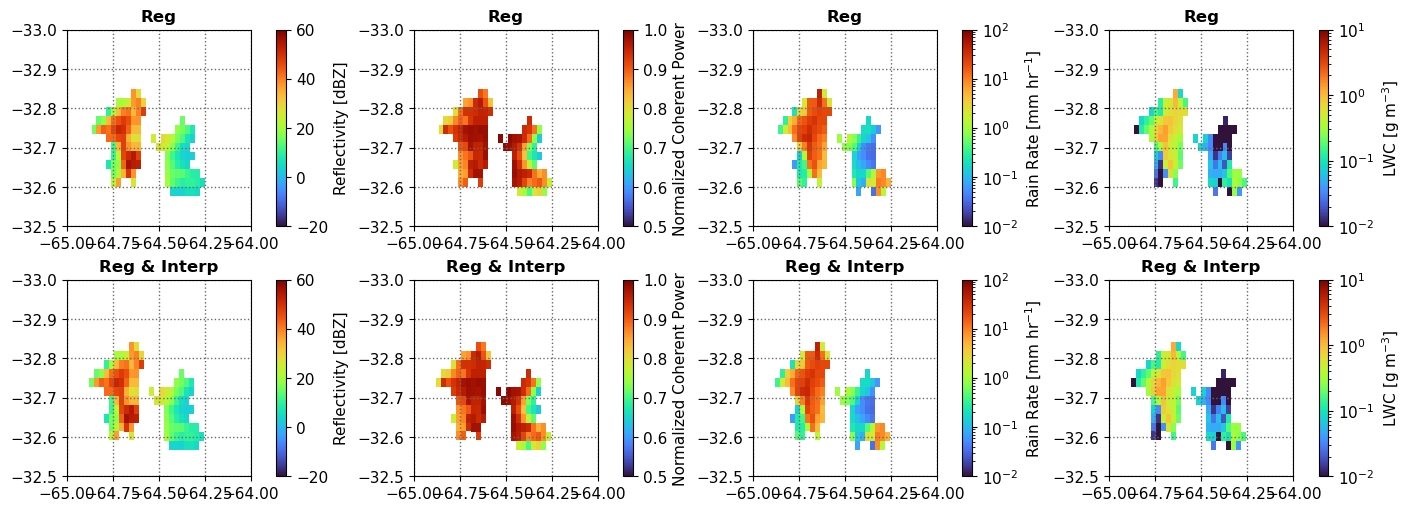

In [54]:
if True:
    fig = plt.figure(figsize=(14,5),constrained_layout=True)
    ax1 = fig.add_subplot(241)
    ax2 = fig.add_subplot(242)
    ax3 = fig.add_subplot(243)
    ax4 = fig.add_subplot(244)
    ax5 = fig.add_subplot(245)
    ax6 = fig.add_subplot(246)
    ax7 = fig.add_subplot(247)
    ax8 = fig.add_subplot(248)
    
    dumi=1
    axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]
    Fontsize=11
    for ax in axlist:
        ax.tick_params(labelsize=Fontsize)
        ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
    # Reflectivity
    ref_levs = np.arange(-20,61,1)
    ref_plot=ax1.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],REFL_reg[dumi,:,:],vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax1.set_title('Reg',fontweight='bold')
    
    ref_plot=ax5.pcolormesh(wrf_lon,wrf_lat,REFL_reg_interp[dumi,:,:],vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax5.set_title('Reg & Interp',fontweight='bold')
    
    # NCP
    ncp_levs = np.arange(0.5,1.01,0.01)
    ncp_plot=ax2.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],ncp_reg[dumi,:,:],vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax2.set_title('Reg',fontweight='bold')
    
    ncp_plot=ax6.pcolormesh(wrf_lon,wrf_lat,ncp_reg_interp[dumi,:,:],vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax6.set_title('Reg & Interp',fontweight='bold')
    
    # Rain Rate
    rr_levs = 10.**np.arange(-2,2.1,0.1)
    rr_plot=ax3.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],non_ref_vars_reg[non_ref_vars_keys[0]][dumi,:,:],cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax3.set_title('Reg',fontweight='bold')
    
    rr_plot=ax7.pcolormesh(wrf_lon,wrf_lat,non_ref_vars_reg_interp[non_ref_vars_keys[0]][dumi,:,:],cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax7.set_title('Reg & Interp',fontweight='bold')
    
    # lwc
    lwc_levs = 10.**np.arange(-2,1.1,0.1)
    lwc_plot=ax4.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],non_ref_vars_reg[non_ref_vars_keys[1]][dumi,:,:],cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax4.set_title('Reg',fontweight='bold')
    
    lwc_plot=ax8.pcolormesh(wrf_lon,wrf_lat,non_ref_vars_reg_interp[non_ref_vars_keys[1]][dumi,:,:],cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax8.set_title('Reg & Interp',fontweight='bold')
    
    #for ax in axlist:
    #    ax.plot(longitude_reg[0,45,45],latitude_reg[0,45,45],markersize=10,marker='*',c='b')
    #    ax.plot(longitude[0,45*6,45*6],latitude[0,45*6,45*6],markersize=5,marker='o',c='red')
    
    for ax in axlist:
        ax.set_xlim(-65,-64)
        ax.set_ylim(-32.5,-33)
    
    plt.show()
    plt.close()


# Testing to plot coarse-grained vs. coarse-grained AND regridded maps
## Column-maximum

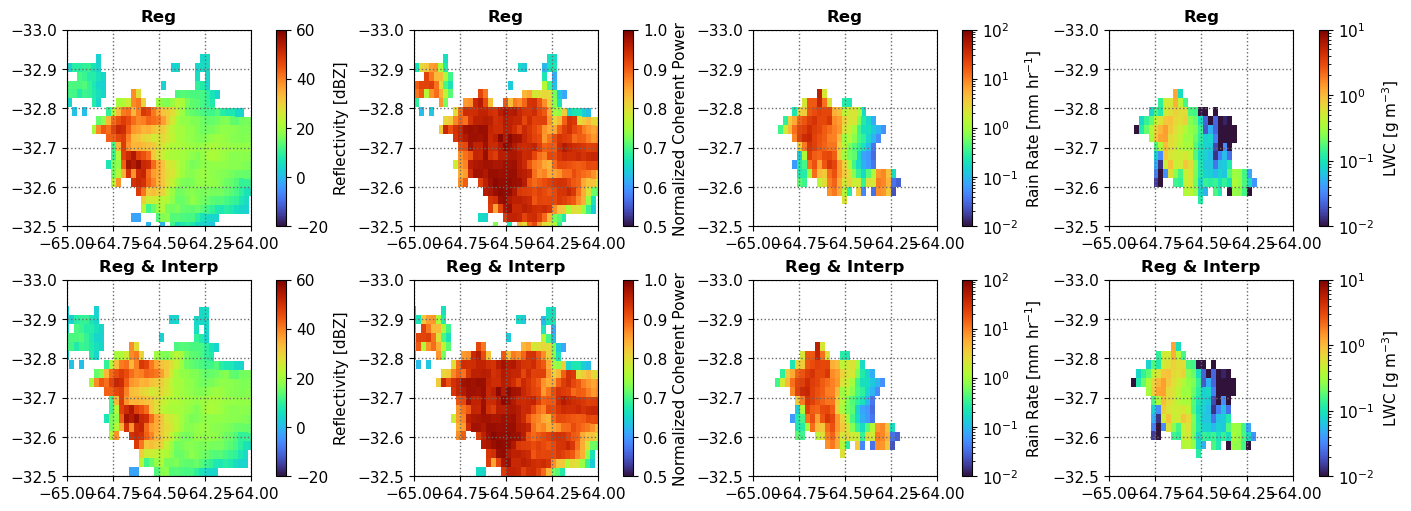

In [56]:
if True:
    fig = plt.figure(figsize=(14,5),constrained_layout=True)
    ax1 = fig.add_subplot(241)
    ax2 = fig.add_subplot(242)
    ax3 = fig.add_subplot(243)
    ax4 = fig.add_subplot(244)
    ax5 = fig.add_subplot(245)
    ax6 = fig.add_subplot(246)
    ax7 = fig.add_subplot(247)
    ax8 = fig.add_subplot(248)
    
    axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]
    Fontsize=11
    for ax in axlist:
        ax.tick_params(labelsize=Fontsize)
        ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
    # Reflectivity
    ref_levs = np.arange(-20,61,1)
    ref_plot=ax1.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(REFL_reg,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax1.set_title('Reg',fontweight='bold')
    
    ref_plot=ax5.pcolormesh(wrf_lon,wrf_lat,np.nanmax(REFL_reg_interp,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax5.set_title('Reg & Interp',fontweight='bold')
    
    # NCP
    ncp_levs = np.arange(0.5,1.01,0.01)
    ncp_plot=ax2.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(ncp_reg,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax2.set_title('Reg',fontweight='bold')
    
    ncp_plot=ax6.pcolormesh(wrf_lon,wrf_lat,np.nanmax(ncp_reg_interp,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax6.set_title('Reg & Interp',fontweight='bold')
    
    # Rain Rate
    rr_levs = 10.**np.arange(-2,2.1,0.1)
    rr_plot=ax3.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(non_ref_vars_reg[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax3.set_title('Reg',fontweight='bold')
    
    rr_plot=ax7.pcolormesh(wrf_lon,wrf_lat,np.nanmax(non_ref_vars_reg_interp[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax7.set_title('Reg & Interp',fontweight='bold')
    
    # lwc
    lwc_levs = 10.**np.arange(-2,1.1,0.1)
    lwc_plot=ax4.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(non_ref_vars_reg[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax4.set_title('Reg',fontweight='bold')
    
    lwc_plot=ax8.pcolormesh(wrf_lon,wrf_lat,np.nanmax(non_ref_vars_reg_interp[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax8.set_title('Reg & Interp',fontweight='bold')
    
    for ax in axlist:
        ax.set_xlim(-65,-64)
        ax.set_ylim(-32.5,-33)
    
    plt.show()
    plt.close()

# Testing to plot original versus convolution data

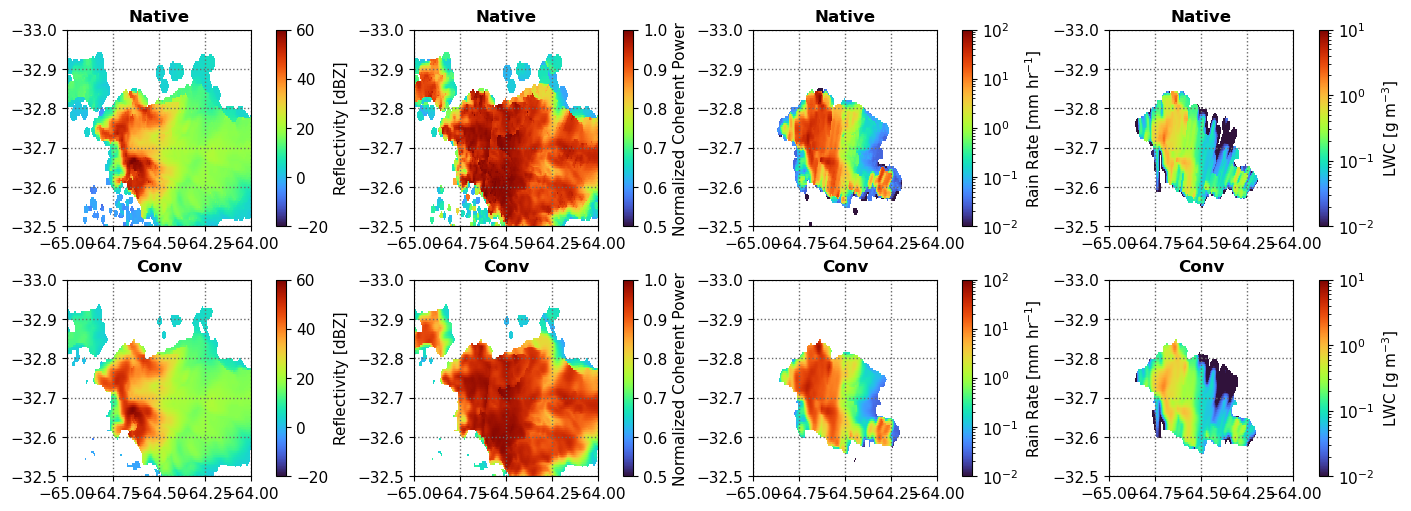

In [60]:
if True:
    fig = plt.figure(figsize=(14,5),constrained_layout=True)
    ax1 = fig.add_subplot(241)
    ax2 = fig.add_subplot(242)
    ax3 = fig.add_subplot(243)
    ax4 = fig.add_subplot(244)
    ax5 = fig.add_subplot(245)
    ax6 = fig.add_subplot(246)
    ax7 = fig.add_subplot(247)
    ax8 = fig.add_subplot(248)
    
    axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]
    Fontsize=11
    for ax in axlist:
        ax.tick_params(labelsize=Fontsize)
        ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
    # Reflectivity
    ref_levs = np.arange(-20,61,1)
    ref_plot=ax1.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(REFL,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax1.set_title('Native',fontweight='bold')
    
    ref_plot=ax5.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.nanmax(REFL_conv,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax5.set_title('Conv',fontweight='bold')
    
    # NCP
    ncp_levs = np.arange(0.5,1.01,0.01)
    ncp_plot=ax2.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(ncp,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax2.set_title('Native',fontweight='bold')
    
    ncp_plot=ax6.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.nanmax(ncp_conv,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax6.set_title('Conv',fontweight='bold')
    
    
    # Rain Rate
    rr_levs = 10.**np.arange(-2,2.1,0.1)
    rr_plot=ax3.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(non_ref_vars[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax3.set_title('Native',fontweight='bold')
    
    rr_plot=ax7.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.nanmax(vars_conv[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax7.set_title('Conv',fontweight='bold')
    
    # lwc
    lwc_levs = 10.**np.arange(-2,1.1,0.1)
    lwc_plot=ax4.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(non_ref_vars[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax4.set_title('Native',fontweight='bold')
    
    lwc_plot=ax8.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.nanmax(vars_conv[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax8.set_title('Conv',fontweight='bold')
    
    for ax in axlist:
        ax.set_xlim(-65,-64)
        ax.set_ylim(-32.5,-33)
    
    plt.show()
    plt.close()


# Testing to plot original versus coarse-grained data

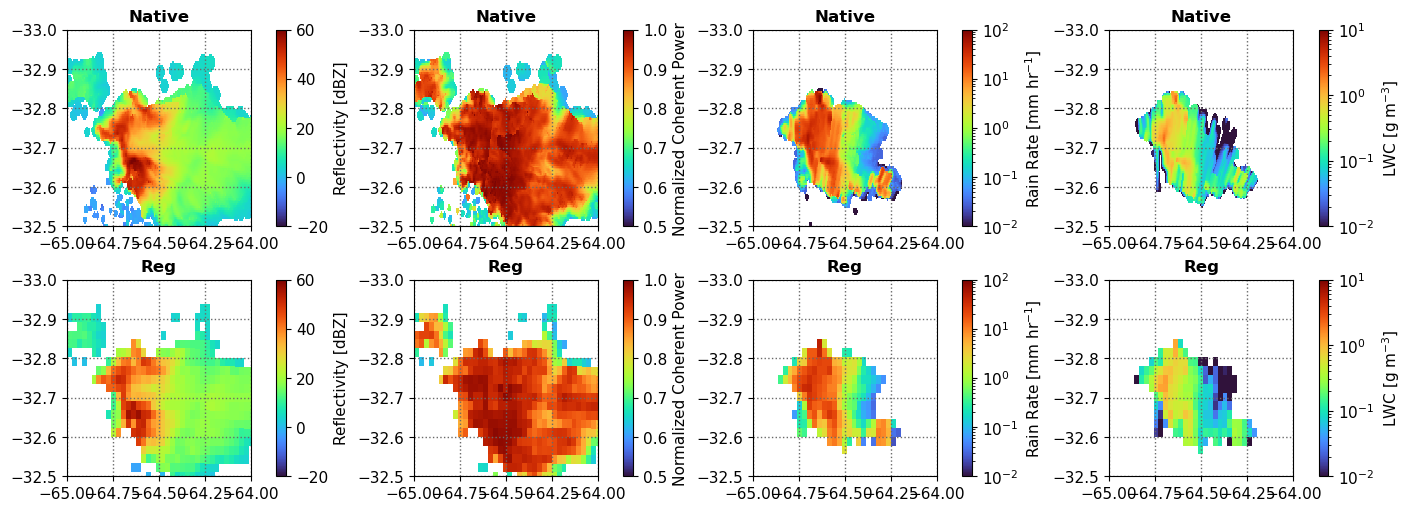

In [62]:
if True:
    fig = plt.figure(figsize=(14,5),constrained_layout=True)
    ax1 = fig.add_subplot(241)
    ax2 = fig.add_subplot(242)
    ax3 = fig.add_subplot(243)
    ax4 = fig.add_subplot(244)
    ax5 = fig.add_subplot(245)
    ax6 = fig.add_subplot(246)
    ax7 = fig.add_subplot(247)
    ax8 = fig.add_subplot(248)
    
    axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]
    Fontsize=11
    for ax in axlist:
        ax.tick_params(labelsize=Fontsize)
        ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
    # Reflectivity
    ref_levs = np.arange(-20,61,1)
    ref_plot=ax1.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(REFL,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax1.set_title('Native',fontweight='bold')
    
    ref_plot=ax5.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(REFL_reg,axis=0),vmin=ref_levs[0],vmax=ref_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ref_plot,pad=0.01)
    cbar.ax.set_ylabel('Reflectivity [dBZ]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax5.set_title('Reg',fontweight='bold')
    
    # NCP
    ncp_levs = np.arange(0.5,1.01,0.01)
    ncp_plot=ax2.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(ncp,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax2.set_title('Native',fontweight='bold')
    
    ncp_plot=ax6.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(ncp_reg,axis=0),vmin=ncp_levs[0],vmax=ncp_levs[-1],cmap='turbo')
    cbar = fig.colorbar(ncp_plot,pad=0.01)
    cbar.ax.set_ylabel('Normalized Coherent Power',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax6.set_title('Reg',fontweight='bold')
    
    
    # Rain Rate
    rr_levs = 10.**np.arange(-2,2.1,0.1)
    rr_plot=ax3.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(non_ref_vars[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax3.set_title('Native',fontweight='bold')
    
    rr_plot=ax7.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(non_ref_vars_reg[non_ref_vars_keys[0]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=rr_levs[0],vmax=rr_levs[-1]))
    cbar = fig.colorbar(rr_plot,pad=0.01)
    cbar.ax.set_ylabel('Rain Rate [mm hr$^{-1}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax7.set_title('Reg',fontweight='bold')
    
    # lwc
    lwc_levs = 10.**np.arange(-2,1.1,0.1)
    lwc_plot=ax4.pcolormesh(longitude[0,:,:],latitude[0,:,:],np.max(non_ref_vars[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax4.set_title('Native',fontweight='bold')
    
    lwc_plot=ax8.pcolormesh(longitude_reg[0,:,:],latitude_reg[0,:,:],np.nanmax(non_ref_vars_reg[non_ref_vars_keys[1]],axis=0),cmap='turbo',norm=mpl.colors.LogNorm(vmin=lwc_levs[0],vmax=lwc_levs[-1]))
    cbar = fig.colorbar(lwc_plot,pad=0.01)
    cbar.ax.set_ylabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    ax8.set_title('Reg',fontweight='bold')
    
    for ax in axlist:
        ax.set_xlim(-65,-64)
        ax.set_ylim(-32.5,-33)
    
    plt.show()
    plt.close()
